# STEP B- MULTIPLE INSTANCE DETECTION

## Introduction
The provided code performs object detection using the **SIFT** (Scale-Invariant Feature Transform) algorithm and the **FLANN** (Fast Library for Approximate Nearest Neighbors) based matcher. It aims to identify and locate multiple instances of query images within a set of training images using **GHT**. 

## Code Implementation
In the first part, we import all the important libraries, then we load scene and model images and compute their features SIFT.

In [1]:
import numpy as np
import cv2
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d
import scipy.ndimage.filters as filters
import warnings
warnings.filterwarnings('ignore')

In [2]:
scene_paths=["m1.png","m2.png","m3.png","m4.png","m5.png"]
model_paths=["0.jpg","1.jpg","11.jpg","19.jpg","24.jpg","25.jpg","26.jpg"]

def load_images(paths,dir):
    return [cv2.cvtColor(cv2.imread("object_detection_project/"+dir+path),cv2.COLOR_BGR2RGB) for path in paths]
  
train_images=load_images(scene_paths,"scenes/")
query_images=load_images(model_paths,"models/")
sift=cv2.xfeatures2d.SIFT_create()
train_features={index:sift.detectAndCompute(train_image,None) for index,train_image in enumerate(train_images)}
query_features={index:sift.detectAndCompute(query_image,None) for index,query_image in enumerate(query_images)}


Now we compute matches between query and train descriptors using the Nearest Neighbour Search provided by FLANN and the ratio of distances by Lowe, tuning the threshold _lowe_.

Then, the `get_roi` function extracts a region of interest from the image based on four corner points and the two vertices (upper left and bottom right ones) used to define the bounding box.

Finally, the `print_output` function is designed to annotate and print details about the detected instances of the query image within the training image. It draws bounding boxes around the detected instances and prints their positions and dimensions.

In [3]:
def compute_matches(FLANN_INDEX_KDTREE,trees,checks,k,lowe,des_query,des_train):
  index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = trees)
  search_params = dict(checks = checks)
  flann = cv2.FlannBasedMatcher(index_params, search_params)
  matches = flann.knnMatch(des_query,des_train,k=2)
  # store all the good matches as per Lowe's ratio test.
  good = []
  for m,n in matches:
      if m.distance < lowe*n.distance:
          good.append(m)
  return good

def get_roi(x1,x2,x3,x4,y1,y2,y3,y4,img):
  top_left_x = int(max(0,min([x1,x2,x3,x4])))
  top_left_y = int(max(0, min([y1,y2,y3,y4])))
  bot_right_x = int(max([x1,x2,x3,x4]))
  bot_right_y = int(max([y1,y2,y3,y4]))
  return (img[top_left_y:bot_right_y, top_left_x:bot_right_x],(top_left_x,top_left_y),(bot_right_x,bot_right_y))


def print_output(query_idx,rectangles,img_train):
    print("Product {} - {} Instances Found:".format(query_idx,len(rectangles)))
    for index in range(len(rectangles)):
        min_x=min(rectangles[index],key=lambda x: x[0])[0]
        min_y=min(rectangles[index],key=lambda x:x[1])[1]
        max_x=max(rectangles[index],key=lambda x: x[0])[0]
        max_y=max(rectangles[index],key=lambda x:x[1])[1]
        s=(min_x,min_y)
        e=(max_x,max_y)
        width=int(max_x)-int(min_x)
        height=int(max_y)-int(min_y)
        centre=(int((min_x+max_x)/2),int((min_y+max_y)/2))
        cv2.rectangle(img_train, s,e, (0,255,0), thickness = 5)
        cv2.circle(img_train, centre, radius=5, color=(0, 255, 0), thickness=-1)
        print("\tInstance {} [ position: (({},{}), width: {} px, height: {} px]".format(index,centre[0],centre[1],width,height))

    return len(rectangles)

The `compute_feature_vector` is designed to robustly locate instances of query objects within training images. 

This involves several steps:
- Extracting keypoints and descriptors.
- Matching keypoints and filtering matches.
- Computing feature vectors considering the canonical scale and rotation of the matching keypoints and voting in a discretized accumulator array.
- Identifying local maxima in the accumilator array.
- Refining potential object locations using homography and color consistency checks.

In [4]:
def compute_feature_vector(query_kp,train_kp,train_shape,N_HORIZONTAL_BINS = 15,N_VERTICAL_BINS = 10):
  query_xy = np.array([kp.pt for kp in query_kp])
  train_xy = np.array([kp.pt for kp in train_kp])
  N_HORIZONTAL_BINS = train_shape[1] // 100
  N_VERTICAL_BINS = train_shape[0] // 120
  # Baricenter of matched query keypoints 
  bary_x,bary_y = query_xy.mean(axis = 0)
  scale_ratio = np.array([kp_t.size / kp_q.size for kp_t,kp_q in zip(train_kp,query_kp)])
  angle_diff = np.array([kp_t.angle - kp_q.angle for kp_t,kp_q in zip(train_kp,query_kp)])
  Vx_i = np.array(query_xy[:,0] - bary_x)
  Vy_i = np.array(query_xy[:,1] - bary_y)
  pred_bary_x = train_xy[:,0] + scale_ratio * (np.cos(angle_diff) * Vx_i - np.sin(angle_diff) * Vy_i)
  pred_bary_y = train_xy[:,1] + scale_ratio * (np.sin(angle_diff) * Vx_i - np.cos(angle_diff) * Vy_i)
  interp_x = interp1d([0,train_shape[1]],[0,N_HORIZONTAL_BINS])
  interp_y = interp1d([0,train_shape[0]],[0,N_VERTICAL_BINS])
  votes_x = [int(interp_x(pred_x)) if pred_x >= 0 and pred_x <= train_shape[1] else -1 for pred_x in pred_bary_x]
  votes_y = [int(interp_y(pred_y)) if pred_y >= 0 and pred_y <= train_shape[0] else -1 for pred_y in pred_bary_y]
  votes = {}
  votes_matrix = np.zeros((N_VERTICAL_BINS,N_HORIZONTAL_BINS))
  for index,(votes_x,votes_y) in enumerate(zip(votes_x,votes_y)):
    if votes_x >= 0 and votes_y >= 0:
      votes.setdefault((votes_y,votes_x),[]).append((train_kp[index],query_kp[index]))
      votes_matrix[votes_y,votes_x] += 1
  return (votes,votes_matrix)

def grab_neigh_indexes(max_index):
  neigh_indexes = []
  for i in range(-1,2):
    for j in range(-2,3):
      neigh_indexes.append((max_index[0] + i,max_index[1] + j))
  return neigh_indexes

Then, we use Non-Maxima Suppression (NMS) to filter out multiple overlapping bounding boxes for the same object, leaving only the most confident one. 
This is essential for preventing multiple detections of the same object and ensuring that each detected object is represented by a single, well-defined bounding box.
The function iterates through the sorted polygons. For each polygon (poly), it checks if it overlaps significantly with any polygon already in the maxima list.

To measure the overlap we used the Intersection over Union (IoU) between two polygons. If the IoU is greater than or equal to the specified threshold (IOU_THRES), the polygons are considered to overlap.
If a polygon does not overlap significantly with any polygon in maxima, it is added to the maxima list.

In [5]:

def bb_intersection_over_union(rect1, rect2):
    # Calculate the overlapping regions along the x-axis and y-axis
    x_overlap = max(0, min(rect1[2][0], rect2[2][0]) - max(rect1[0][0], rect2[0][0]))
    y_overlap = max(0, min(rect1[2][1], rect2[2][1]) - max(rect1[0][1], rect2[0][1]))

    # Compute the area of the overlapping region
    intersection_area = x_overlap * y_overlap
    x_min = min(rect1[0][0], rect2[0][0])
    y_min = min(rect1[0][1], rect2[0][1])
    x_max = max(rect1[2][0], rect2[2][0])
    y_max = max(rect1[2][1], rect2[2][1])

    # Compute the area of the union rectangle
    union_area = (x_max - x_min) * (y_max - y_min)
    if intersection_area and union_area:
      return intersection_area/union_area
    else:
      return 0
      
def area(x):            
  return (x[2][1]-x[0][1])*(x[2][0]-x[0][0])

def non_maxima_suppression(rectangles, IOU_THRES = 0.1, MIN_DIAG = 80, MAX_DIAG = 700):
  x_dims = np.array([e[0] - s[0] for s,e in rectangles])
  y_dims = np.array([e[1] - s[1] for s,e in rectangles])
  filtered_rectangles = []
  for index in range(len(rectangles)):
    if x_dims[index] >= 300 and x_dims[index] <= 400:
      if y_dims[index] >= 300 and y_dims[index] <= 500:
        filtered_rectangles.append(rectangles[index])
  rectangles = filtered_rectangles
  if len(rectangles):
    polygons=[[(s[0],s[1]),(e[0],s[1]),(e[0],e[1]),(s[0],e[1])] for s,e in rectangles]
    maxima = []
    polygons.sort(key=lambda x: area(x), reverse=True)
    for index,poly in enumerate(polygons):
      found = False
      for poly_2 in maxima:
        if bb_intersection_over_union(poly,poly_2) >= IOU_THRES or bb_intersection_over_union(poly_2,poly) >= IOU_THRES:
          found = True
      if not found:
         maxima.append(poly)
    return maxima
  else:
     return []

The `instance_detection` function is the core of the object detection process. It identifies instances of the query object within the target image by matching features, filtering matches, and drawing bounding boxes around detected objects.

It also includes the voting step and Non-Maxima Suppression to refine the results and ensure accurate detection.


Product 0 - 1 Instances Found:
	Instance 0 [ position: ((939,162), width: 313 px, height: 324 px]
Product 4 - 2 Instances Found:
	Instance 0 [ position: ((185,233), width: 363 px, height: 467 px]
	Instance 1 [ position: ((548,232), width: 339 px, height: 464 px]
Product 5 - 1 Instances Found:
	Instance 0 [ position: ((1259,230), width: 323 px, height: 449 px]
Product 6 - 1 Instances Found:
	Instance 0 [ position: ((922,231), width: 337 px, height: 463 px]


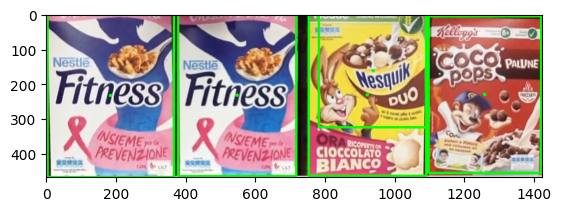

Product 0 - 1 Instances Found:
	Instance 0 [ position: ((178,302), width: 348 px, height: 462 px]
Product 1 - 2 Instances Found:
	Instance 0 [ position: ((849,261), width: 320 px, height: 416 px]
	Instance 1 [ position: ((1179,261), width: 307 px, height: 411 px]


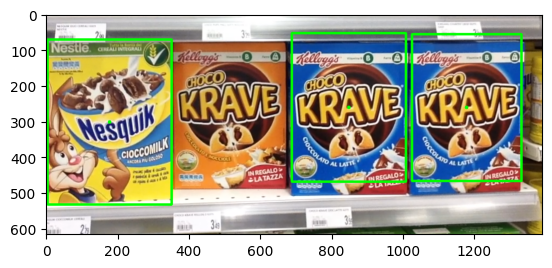

No Homography was found
Product 3 - 1 Instances Found:
	Instance 0 [ position: ((1232,190), width: 302 px, height: 381 px]
Product 5 - 2 Instances Found:
	Instance 0 [ position: ((557,228), width: 339 px, height: 457 px]
	Instance 1 [ position: ((888,227), width: 330 px, height: 450 px]
Product 6 - 1 Instances Found:
	Instance 0 [ position: ((192,230), width: 365 px, height: 461 px]


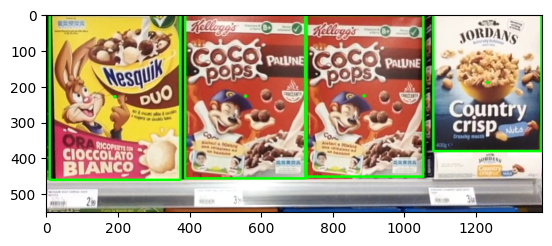

Product 4 - 2 Instances Found:
	Instance 0 [ position: ((537,223), width: 363 px, height: 446 px]
	Instance 1 [ position: ((176,228), width: 352 px, height: 457 px]
Product 5 - 2 Instances Found:
	Instance 0 [ position: ((1270,216), width: 333 px, height: 432 px]
	Instance 1 [ position: ((1585,218), width: 318 px, height: 436 px]
Product 6 - 1 Instances Found:
	Instance 0 [ position: ((920,222), width: 345 px, height: 444 px]


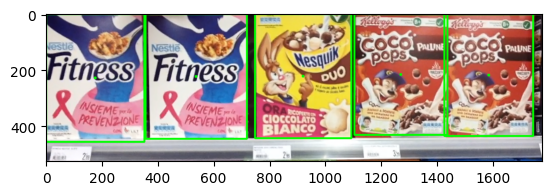

Product 1 - 2 Instances Found:
	Instance 0 [ position: ((498,723), width: 317 px, height: 418 px]
	Instance 1 [ position: ((833,713), width: 310 px, height: 423 px]
Product 2 - 1 Instances Found:
	Instance 0 [ position: ((159,712), width: 319 px, height: 413 px]
Product 3 - 1 Instances Found:
	Instance 0 [ position: ((907,192), width: 300 px, height: 384 px]
Product 5 - 2 Instances Found:
	Instance 0 [ position: ((562,229), width: 333 px, height: 457 px]
	Instance 1 [ position: ((234,223), width: 338 px, height: 447 px]


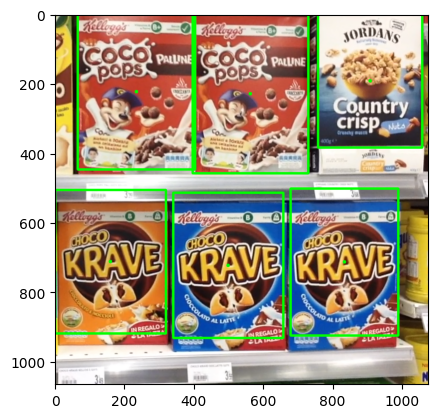

In [6]:
def instance_detection(query_idx,img_query, img_train, query_features, train_features, min_match_count = 0, COLOR_DIFF_THRESHOLD = 50):
    rectangles=[]
    good = compute_matches(0,5,50,2,0.55,query_features[1],train_features[1])
    # If it's a good match, then proceed with the detection
    if len(good)>min_match_count:
        query_pts = np.array([query_features[0][m.queryIdx] for m in good ])
        train_pts = np.array([train_features[0][m.trainIdx] for m in good ])
        votes,votes_matrix=compute_feature_vector(query_pts,train_pts,img_train.shape)
        data_max = filters.maximum_filter(votes_matrix, (2,4))
        indexes = np.where(data_max == votes_matrix, votes_matrix, 0)
        indexes = [(row[0],row[1])for row in np.argwhere(indexes > 0)]
        for index in indexes:
          if votes_matrix[index] >= 2:
            neigh_indexes = grab_neigh_indexes(index)
            neigh_votes = [vote for index in neigh_indexes for vote in votes.get(index,[])]
            src_points = np.float32([vote[1].pt for vote in neigh_votes]).reshape(-1,1,2)
            dst_points = np.float32([vote[0].pt for vote in neigh_votes]).reshape(-1,1,2)
            if len(src_points) >= 4:
              M, mask = cv2.findHomography(src_points, dst_points, cv2.RANSAC, 2.0)
              if M is None:
                  print ("No Homography was found")
              else:
                  h,w,_ = img_query.shape
                  # Generate and plot the rectangle into the target image
                  pts = np.float32([ [0,0],[0,h-1],[w-1,h-1],[w-1,0] ]).reshape(-1,1,2)
                  dst = cv2.perspectiveTransform(pts,M)
                  roi,start,end = get_roi(dst[0][0][0],dst[1][0][0],dst[2][0][0],dst[3][0][0],dst[0][0][1],dst[1][0][1],dst[2][0][1],dst[3][0][1],img_train)
                  # If we can manage to obtain a rectangle, then we proceed
                  
                  if len(roi):
                    color_diff = np.linalg.norm(roi.mean(axis = 0).mean(axis = 0) - img_query.mean(axis = 0).mean(axis = 0))
                    if color_diff <= COLOR_DIFF_THRESHOLD:
                     
                      rectangles.append((start,end))
                      # check if the euclidean distance between the colors (mean) of the two rectangle is lower than the chosen threshold

    rectangles = non_maxima_suppression(np.array(rectangles))

        # Draw the bounding box and center pixel of every blob
    if len(rectangles):
        print_output(query_idx,rectangles,img_train)

    return len(rectangles)
# Iterating among all scenes and looking for the query object.

for index_train in range(len(train_images)):
  for index_query in range(len(query_images)):
    rectangles=instance_detection(index_query,query_images[index_query],train_images[index_train],query_features[index_query],train_features[index_train])
  plt.imshow(train_images[index_train])
  plt.show()
